# NVDA — leaderboard and interval calibration

Three questions about every forecaster in the registry, kept separate on purpose:

1. **Is it accurate?** — the CRPS leaderboard.
2. **Is it honest?** — the coverage-vs-sharpness chart. A forecaster can score well on
   average while claiming far more or far less certainty than it has, and the leaderboard
   alone will not show it.
3. **What did it actually predict?** — every prediction in full, and a line chart of
   forecasts against the actual price.

Everything here reads the committed prediction YAMLs by **globbing the registry**, so a
predictor appears in both views the moment its results land in
`data/predictions/<spec_id>/`. Re-running this notebook is the whole update path when the
news-grounded and adaptive agents arrive — there is no code to change.

> Run from the repository root, after `uv run python scripts/fetch_nvda.py` has populated
> the price cache and `uv run python -m ai_stocks_forecasting.baselines` has produced the
> baseline predictions.

In [1]:
import pandas as pd
from ai_stocks_forecasting.analysis import leaderboard_with_uncertainty, per_horizon_crps
from ai_stocks_forecasting.charts import (
    coverage_sharpness,
    coverage_sharpness_table,
    load_scored_frame,
    predicted_vs_actual,
)
from ai_stocks_forecasting.data import build_nvda_service


SPEC_ID = "nvda_backtest"  # swap to "nvda_eval" for the protected 2026 window

pd.set_option("display.width", 160)

data_service = build_nvda_service()
frame = load_scored_frame(SPEC_ID, data_service)

print(f"{SPEC_ID}: {len(frame)} scored predictions across {frame['predictor'].nunique()} predictors")
print(f"predictors: {', '.join(sorted(frame['predictor'].unique()))}")

nvda_backtest: 290 scored predictions across 2 predictors
predictors: AutoARIMA (log returns), Naive (last value)


## 1. Leaderboard

CRPS in USD/share, lower is better. The `se` column is the lens for *"is this lead real?"* —
when the gap between two predictors is small next to their standard errors, the ranking is
not meaningful.

**A caveat that applies to the naive row specifically.** `LastValuePredictor` emits a point
mass — every quantile equals the last close — so its CRPS reduces exactly to mean absolute
error. It is not being scored as a distribution at all. Any predictor that *does* emit
intervals is being held to a stricter standard on this table.

In [2]:
leaderboard_with_uncertainty(frame).round(3)

,mean_crps,se,n,family
predictor,,,,
AutoARIMA (log returns),8.174,0.321,145,Numerical ML
Naive (last value),10.665,0.625,145,Baseline


In [3]:
per_horizon_crps(frame).round(2)

,h=5d,h=10d,h=21d,All
predictor,,,,
AutoARIMA (log returns),6.25,7.60,10.48,8.17
Naive (last value),8.23,10.09,13.44,10.67


## 2. Coverage vs sharpness

An 80% prediction interval promises to contain the outcome 80% of the time. This chart plots
what each predictor actually delivered against how wide an interval it needed to deliver it.

- **On the dashed line** — honest. The further *left* on the line, the more useful: same
  honesty, narrower interval.
- **Below the line** — overconfident. The interval is too narrow; the forecaster is claiming
  certainty it does not have.
- **Above the line** — under-confident. Correct, but too vague to act on.

Horizons are faceted rather than pooled, because interval width is in dollars and is not
comparable across them — a \\$12 interval at 21 days is not "worse" than a \\$4 one at 5 days,
it is answering a harder question.

The table is printed first and is not decoration: it is the accessible view of the same
numbers, and the thing to read when two points overlap.

In [4]:
coverage_sharpness_table(frame)

coverage_80  mean_width  mean_crps   n  miscalibration
family       predictor               horizon                                                        
Baseline     Naive (last value)      5               0.00        0.00       8.23  47           -80.0
                                     10              0.00        0.00      10.09  47           -80.0
                                     21              0.00        0.00      13.44  51           -80.0
Numerical ML AutoARIMA (log returns) 5              82.98       32.83       6.25  47             3.0
                                     10             89.36       46.53       7.60  47             9.4
                                     21             98.04       68.51      10.48  51            18.0

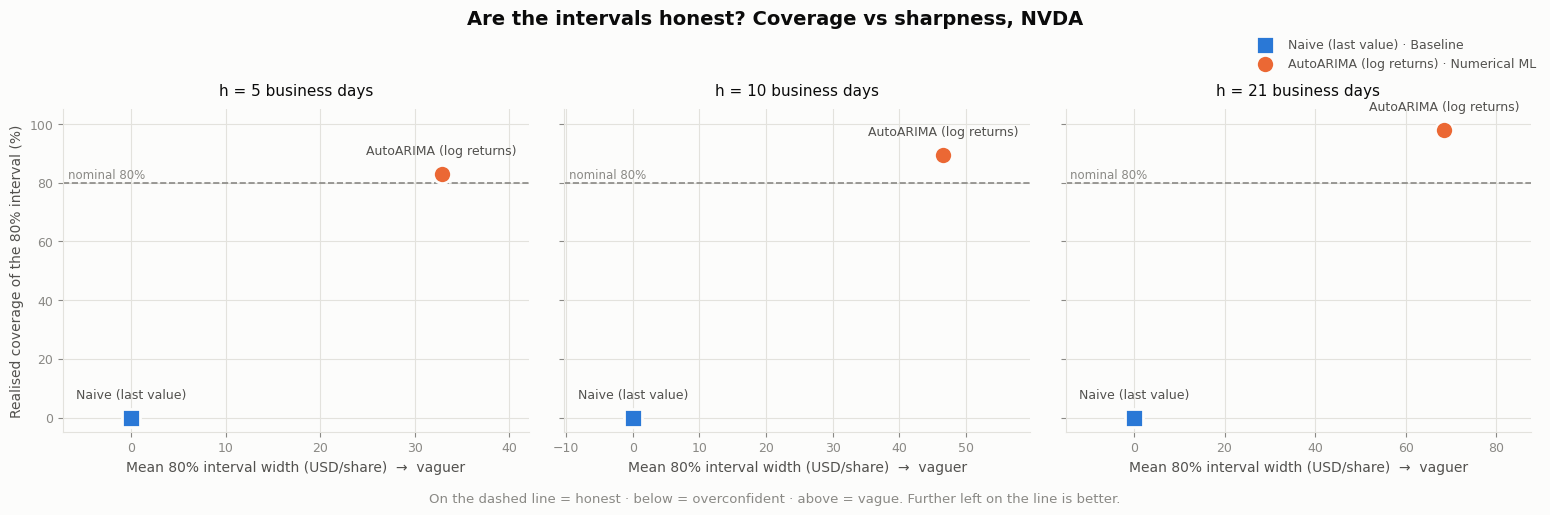

In [5]:
fig, axes = coverage_sharpness(frame)

### Reading the current picture

- **Naive** sits at the origin: zero-width intervals, so zero coverage. It is maximally sharp
  and maximally dishonest, the degenerate corner of the plot. Its CRPS is just its absolute
  error.
- **AutoARIMA (log returns)** sits **above** the line. Its 80% interval covers 83% / 89% / 98%
  of outcomes at 5 / 10 / 21 days, with average widths of \$33 / \$47 / \$69. It errs on the
  side of *too wide*, increasingly so with horizon. The likely cause is that it estimates
  volatility from the whole history since 1999, including the dot-com era, which was far more
  volatile than 2025. It still beats naive on CRPS at every horizon (8.17 against 10.67),
  because a distribution that is honest-but-wide scores better than a point mass.

**What that means for the agents.** Widening intervals cannot win: the floor is already too
wide. But there is real room to move **left**, because the floor's intervals are wider than
they need to be. An agent that tightens them while keeping coverage near 80% improves CRPS,
and that improvement means it knows something the random walk doesn't. Fitting the baseline
on a shorter window is the cheap numerical version of the same move, and is worth trying
first, so the agents are measured against the best honest floor.

The shock windows are where to look. The floor's CRPS rises from 7.36 in quiet windows to
11.45 in windows containing a ±7% day.

> **Two corrections to earlier versions of this notebook.** The 80% interval used to be
> computed from the 20th and 80th percentiles, which bound a 60% interval, so the coverage
> figures were measured against the wrong target. It now runs from the 10th to the 90th
> percentile. And an earlier version of the baseline fitted AutoARIMA on raw prices, with
> calendar gaps reaching the model as `NaN`. See `02_arima_root_cause.ipynb`.


## 3. Every prediction, in full

Every scored prediction is one row of `frame`, loaded from the YAML files in
`data/predictions/<spec_id>/`. For each predictor, origin (`as_of`) and horizon it holds
the date being forecast, the point forecast, the 10th / 20th / 50th / 80th / 90th
percentiles, the actual price that day, and the error and CRPS.

The cell below shows the first rows. Uncomment the `display.max_rows` line to print all
of them in the notebook, or the `to_csv` line to write them to a CSV you can open in a
spreadsheet. It lands in the gitignored `data/` folder, because prediction dumps are data
and must not be committed.

In [6]:
columns = [
    "predictor",
    "as_of",
    "forecast_date",
    "horizon",
    "q10",
    "q50",
    "point",
    "q90",
    "actual",
    "abs_error",
    "crps",
    "inside80",
]
predictions = frame[columns].sort_values(["predictor", "as_of", "horizon"]).reset_index(drop=True)
two_dp = dict.fromkeys(predictions.select_dtypes("number").columns, 2)  # round numbers, not dates

# pd.set_option("display.max_rows", None)                      # print every row
# To save every row as a CSV (lands in the gitignored data/ folder), uncomment both lines:
# from ai_stocks_forecasting.paths import DATA_DIR
# predictions.to_csv(DATA_DIR / "nvda_backtest_predictions.csv", index=False)

print(f"{len(predictions)} predictions: {predictions['predictor'].value_counts().to_dict()}")
predictions.head(12).round(two_dp)

290 predictions: {'AutoARIMA (log returns)': 145, 'Naive (last value)': 145}


,predictor,as_of,forecast_date,horizon,q10,q50,point,q90,actual,abs_error,crps,inside80
0,AutoARIMA (log returns),2025-01-06,2025-01-13,5,130.36,144.28,144.28,160.49,132.88,11.40,6.85,1.0
1,AutoARIMA (log returns),2025-01-06,2025-02-04,21,118.27,149.42,149.42,183.54,118.34,31.07,18.65,1.0
2,AutoARIMA (log returns),2025-01-13,2025-01-27,10,117.61,137.03,137.03,158.86,118.11,18.92,11.34,1.0
3,AutoARIMA (log returns),2025-01-13,2025-02-11,21,111.56,138.18,138.18,171.38,132.45,5.72,6.87,1.0
4,AutoARIMA (log returns),2025-01-20,2025-01-27,5,125.41,138.99,138.99,154.53,118.11,20.88,14.85,0.0
5,AutoARIMA (log returns),2025-01-20,2025-02-03,10,119.01,138.35,138.35,160.75,116.36,22.00,14.51,0.0
6,AutoARIMA (log returns),2025-01-20,2025-02-18,21,113.50,139.95,139.95,173.27,139.04,0.91,6.25,1.0
7,AutoARIMA (log returns),2025-01-27,2025-02-03,5,128.74,143.53,143.53,159.62,116.36,27.18,20.63,0.0
8,AutoARIMA (log returns),2025-01-27,2025-02-10,10,124.47,145.31,145.31,168.21,133.22,12.08,7.60,1.0
9,AutoARIMA (log returns),2025-01-27,2025-02-25,21,115.44,143.50,143.50,180.96,126.30,17.20,11.26,1.0


To look at a single origin, filter on `as_of`. For example, the three horizons forecast
from 2025-04-07, the Monday after NVDA's April low:

In [7]:
predictions[predictions["as_of"] == "2025-04-07"].round(two_dp)

,predictor,as_of,forecast_date,horizon,q10,q50,point,q90,actual,abs_error,crps,inside80
35,AutoARIMA (log returns),2025-04-07,2025-04-14,5,84.88,94.96,94.96,105.09,110.43,15.47,10.84,0.0
36,AutoARIMA (log returns),2025-04-07,2025-04-21,10,82.06,95.56,95.56,110.44,96.67,1.10,3.08,1.0
37,AutoARIMA (log returns),2025-04-07,2025-05-06,21,76.82,97.59,97.59,120.18,113.25,15.66,9.23,1.0
180,Naive (last value),2025-04-07,2025-04-14,5,94.07,94.07,94.07,94.07,110.43,16.36,16.36,0.0
181,Naive (last value),2025-04-07,2025-04-21,10,94.07,94.07,94.07,94.07,96.67,2.59,2.59,0.0
182,Naive (last value),2025-04-07,2025-05-06,21,94.07,94.07,94.07,94.07,113.25,19.18,19.18,0.0


## 4. Predicted vs actual

The black line is the actual daily close. Each predictor's point forecast is plotted at the
date it was *forecasting*, not the date it was made, so a perfect forecaster would sit
exactly on the black line. The shaded band is its 80% interval. One panel per horizon.

**How to read it.** The naive forecast is the black line shifted right by the horizon, so on
the 21-day panel it visibly lags every turn, most clearly through the April crash and
recovery. A forecaster that adds information turns sooner than that. A band that keeps
missing the black line is overconfident; a band far wider than the line's wiggles is
vague. Today, AutoARIMA's band at 21 days is the second kind.

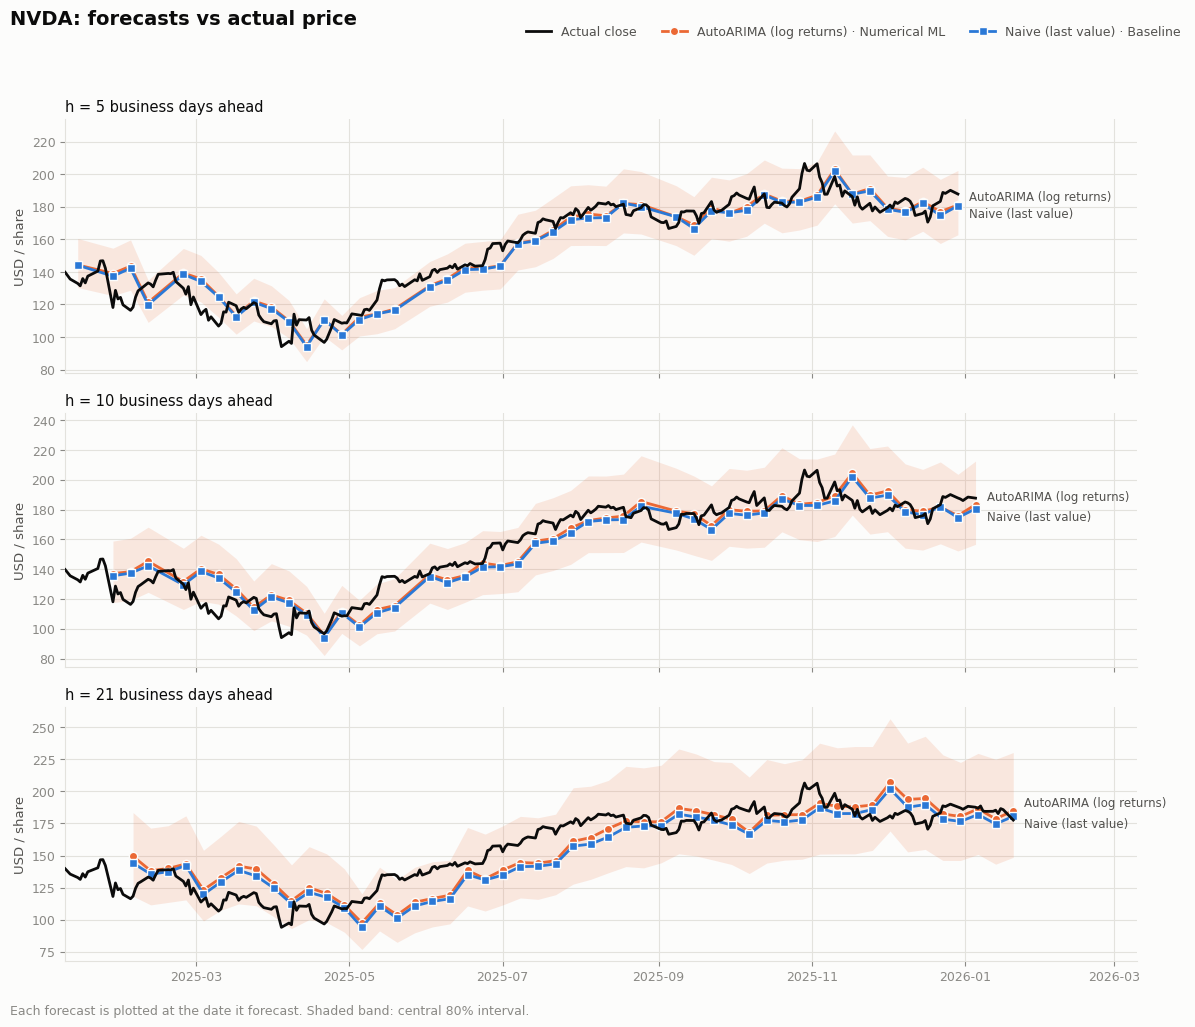

In [8]:
fig, axes = predicted_vs_actual(frame, data_service)

## 5. How this notebook grows

Nothing here is hard-coded to the two baselines.

| When | What to do |
|---|---|
| News-grounded agent predictions land | re-run — the agent appears in the aqua *LLM / Agent* family |
| Adaptive agent predictions land | re-run — a second marker shape within the same family |
| Scoring the protected 2026 window | set `SPEC_ID = "nvda_eval"` and re-run |

Colour encodes the predictor **family**, not the individual predictor, and marker shape
separates predictors within a family. That is deliberate: the categorical palette is only
validated for colourblind separation up to three series on a scatter, so a fourth hue would
fail the check, and tying colour to family rather than to rank means adding a predictor
never repaints the existing ones between phases.